In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"E:\Doc\hotel_bookings.csv")

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [7]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [8]:
df.duplicated().sum()

np.int64(31994)

## Data cleaning

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.drop(columns =['company' , 'agent'] , axis=1, inplace=True)

In [11]:
df['children'].fillna(df['children'].mode()[0] , inplace=True)

C:\Users\Rawan\AppData\Local\Temp\ipykernel_21264\3136728522.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(df['children'].mode()[0] , inplace=True)


In [12]:
df['children'] = df['children'].astype(int)

In [13]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'], errors='coerce')
df['reservation_status_date'] = df['reservation_status_date'].dt.strftime('%Y-%m-%d')

In [14]:
for col in ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status']:
    df[col] = df[col].astype('category')

In [15]:
df['country']=df['country'].fillna(df['country'].mode()[0])

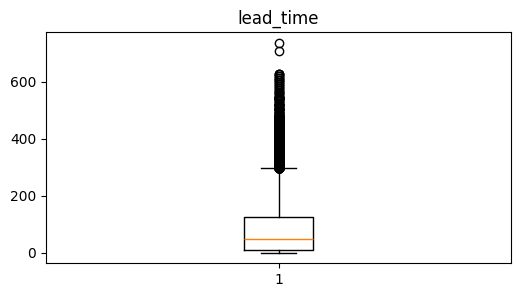

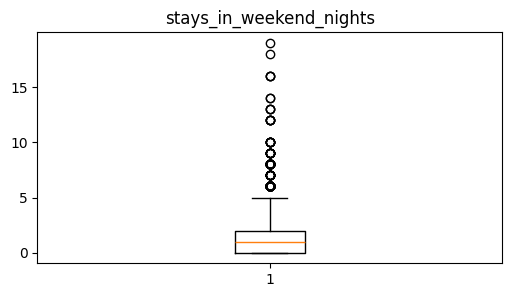

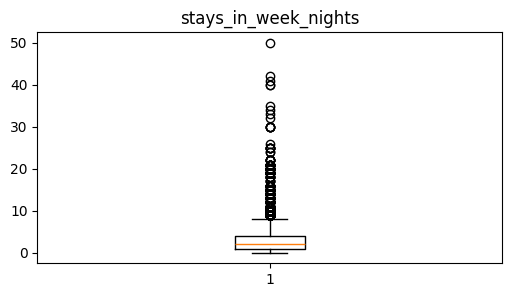

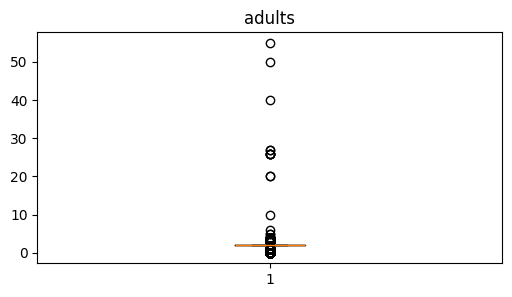

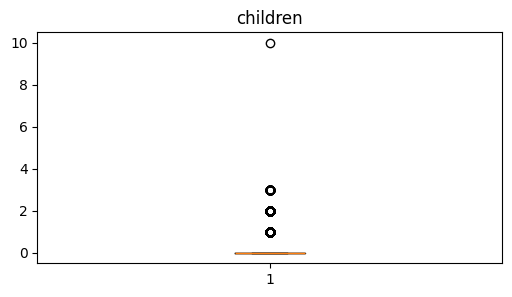

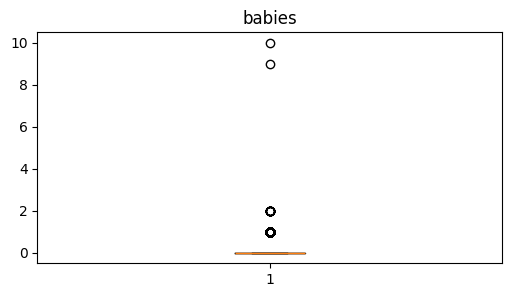

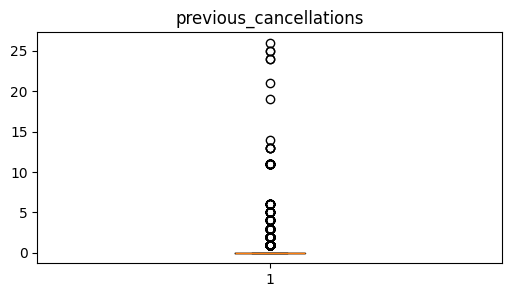

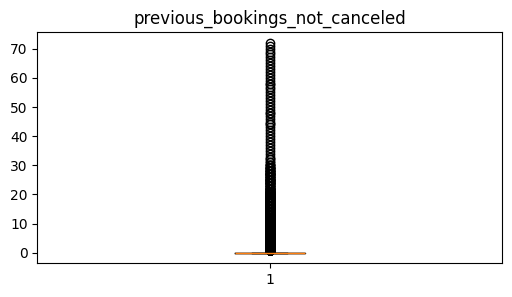

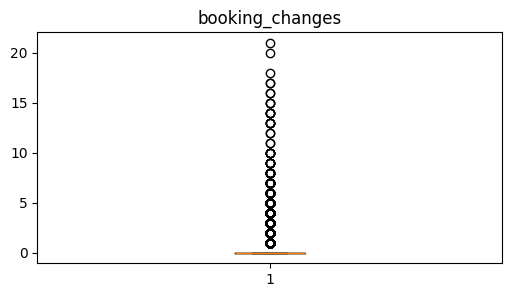

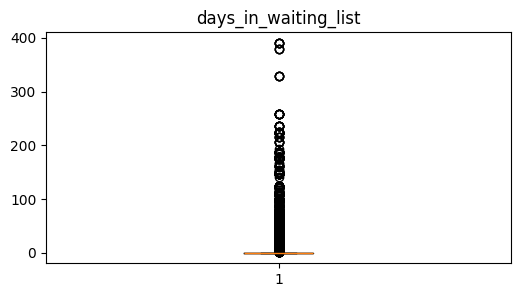

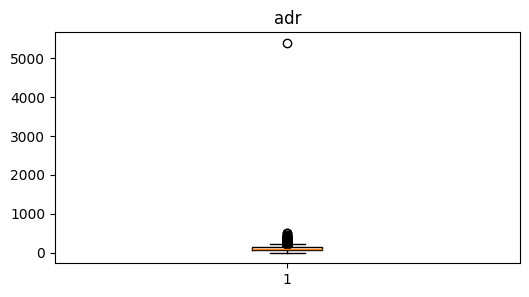

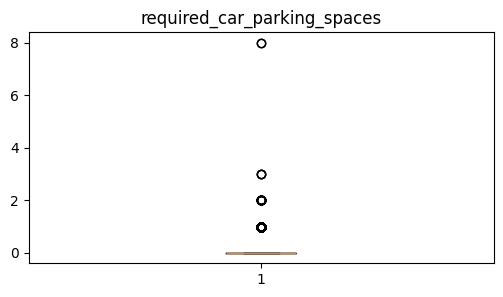

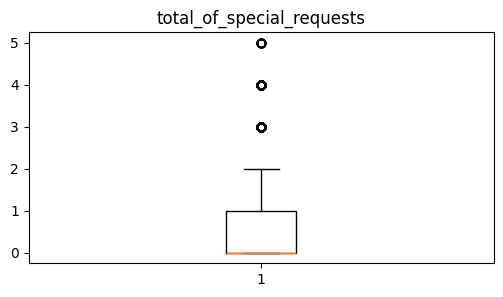

In [16]:
outlier_cols = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

for col in outlier_cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.show()

In [17]:
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

lead_time: 2396 outliers
stays_in_weekend_nights: 220 outliers
stays_in_week_nights: 1531 outliers
adults: 22899 outliers
children: 8364 outliers
babies: 914 outliers
previous_cancellations: 1685 outliers
previous_bookings_not_canceled: 3545 outliers
booking_changes: 15902 outliers
days_in_waiting_list: 860 outliers
adr: 2490 outliers
required_car_parking_spaces: 7313 outliers
total_of_special_requests: 2673 outliers


In [18]:
for col in outlier_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index().tail(15))


lead_time
lead_time
559    2
566    2
573    2
580    2
587    2
594    2
601    2
605    1
608    2
615    2
622    2
626    1
629    2
709    1
737    1
Name: count, dtype: int64

stays_in_weekend_nights
stays_in_weekend_nights
2     26414
3      1150
4      1734
5        70
6       113
7        15
8        60
9        10
10        7
12        5
13        3
14        2
16        3
18        1
19        1
Name: count, dtype: int64

stays_in_week_nights
stays_in_week_nights
20    41
21    15
22     7
24     2
25     6
26     1
30     5
32     1
33     1
34     1
35     1
40     2
41     1
42     1
50     1
Name: count, dtype: int64

adults
adults
0       385
1     16503
2     64497
3      5935
4        60
5         2
6         1
10        1
20        2
26        5
27        2
40        1
50        1
55        1
Name: count, dtype: int64

children
children
0     79032
1      4695
2      3593
3        75
10        1
Name: count, dtype: int64

babies
babies
0     86482
1       897
2     

In [19]:
df[df['adults'] > 10][[
    'hotel',
    'adults',
    'children',
    'babies',
    'reserved_room_type',
    'assigned_room_type',
    'booking_changes',
    'is_canceled'
]]

,hotel,adults,children,babies,reserved_room_type,assigned_room_type,booking_changes,is_canceled
1539,Resort Hotel,40,0,0,A,A,0,1
1587,Resort Hotel,26,0,0,A,A,0,1
1643,Resort Hotel,50,0,0,A,A,0,1
1752,Resort Hotel,26,0,0,A,A,0,1
1884,Resort Hotel,26,0,0,A,A,0,1
1917,Resort Hotel,27,0,0,A,A,0,1
1962,Resort Hotel,27,0,0,A,A,0,1
2003,Resort Hotel,26,0,0,A,A,0,1
2164,Resort Hotel,26,0,0,A,A,0,1
2173,Resort Hotel,55,0,0,A,A,0,1


In [20]:
df[(df['adults'] == 0) & 
   (df['children'] == 0) & 
   (df['babies'] == 0)][
    ['hotel', 'adults', 'children', 'babies', 'is_canceled']
]

,hotel,adults,children,babies,is_canceled
2224,Resort Hotel,0,0,0,0
2409,Resort Hotel,0,0,0,0
3181,Resort Hotel,0,0,0,0
3684,Resort Hotel,0,0,0,0
3708,Resort Hotel,0,0,0,0
...,...,...,...,...,...
115029,City Hotel,0,0,0,0
115091,City Hotel,0,0,0,0
116251,City Hotel,0,0,0,0
116534,City Hotel,0,0,0,0


In [21]:
invalid_bookings = (
    (df['adults'] == 0) &
    (df['children'] == 0) &
    (df['babies'] == 0)
)

df = df[~invalid_bookings].copy()

In [22]:
df[(df['adults'] == 0) & 
   (df['children'] == 0) & 
   (df['babies'] == 0)]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


In [23]:
(df['adr'] < 0).sum()

np.int64(1)

In [24]:
df[df['adr'] < 0][[
    'adr',
    'adults',
    'children',
    'babies',
    'hotel',
    'is_canceled'
]]

,adr,adults,children,babies,hotel,is_canceled
14969,-6.38,2,0,0,Resort Hotel,0


In [25]:
df = df[df['adr'] >= 0].copy()

In [26]:
(df['adr'] < 0).sum()

np.int64(0)

In [27]:
df[df['adr'] > 1000][['adr', 'adults', 'hotel', 'is_canceled']]

,adr,adults,hotel,is_canceled
48515,5400.0,2,City Hotel,1


In [28]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nNumerical Summary:")
display(df.describe())

Shape: (87229, 30)

Columns:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Numerical Summary:


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000
mean,0.275241,79.969700,2016.210343,26.835284,15.815956,1.004574,2.623887,1.879364,0.138899,0.010845,0.038554,0.030403,0.184033,0.268477,0.746300,106.519325,0.084307,0.698942
std,0.446638,86.058295,0.686063,13.669175,8.835520,1.027364,2.039810,0.621727,0.456267,0.113704,0.192530,0.369347,1.733033,0.710612,10.001058,54.890211,0.281660,0.832052
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.250000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.200000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.100000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,18.000000,391.000000,5400.000000,8.000000,5.000000


In [29]:
print("\nCategorical Summary:")
display(df.describe(include='object'))


Categorical Summary:


,arrival_date_month,reservation_status_date
count,87229,87229
unique,12,926
top,August,2016-02-14
freq,11242,211


## Exploratory Data Analysis (EDA)

In [30]:
print(df['is_canceled'].value_counts())

print("\nPercentage:")
print(df['is_canceled'].value_counts(normalize=True) * 100)

is_canceled
0    63220
1    24009
Name: count, dtype: int64

Percentage:
is_canceled
0    72.475897
1    27.524103
Name: proportion, dtype: float64


In [31]:
cancellation_by_hotel = pd.crosstab(
    df['hotel'],
    df['is_canceled']
)

display(cancellation_by_hotel)

is_canceled,0,1
hotel,,
City Hotel,37239,16035
Resort Hotel,25981,7974


In [32]:
cancellation_rate = pd.crosstab(
    df['hotel'],
    df['is_canceled'],
    normalize='index'
) * 100

display(cancellation_rate)

is_canceled,0,1
hotel,,
City Hotel,69.900890,30.099110
Resort Hotel,76.515977,23.484023


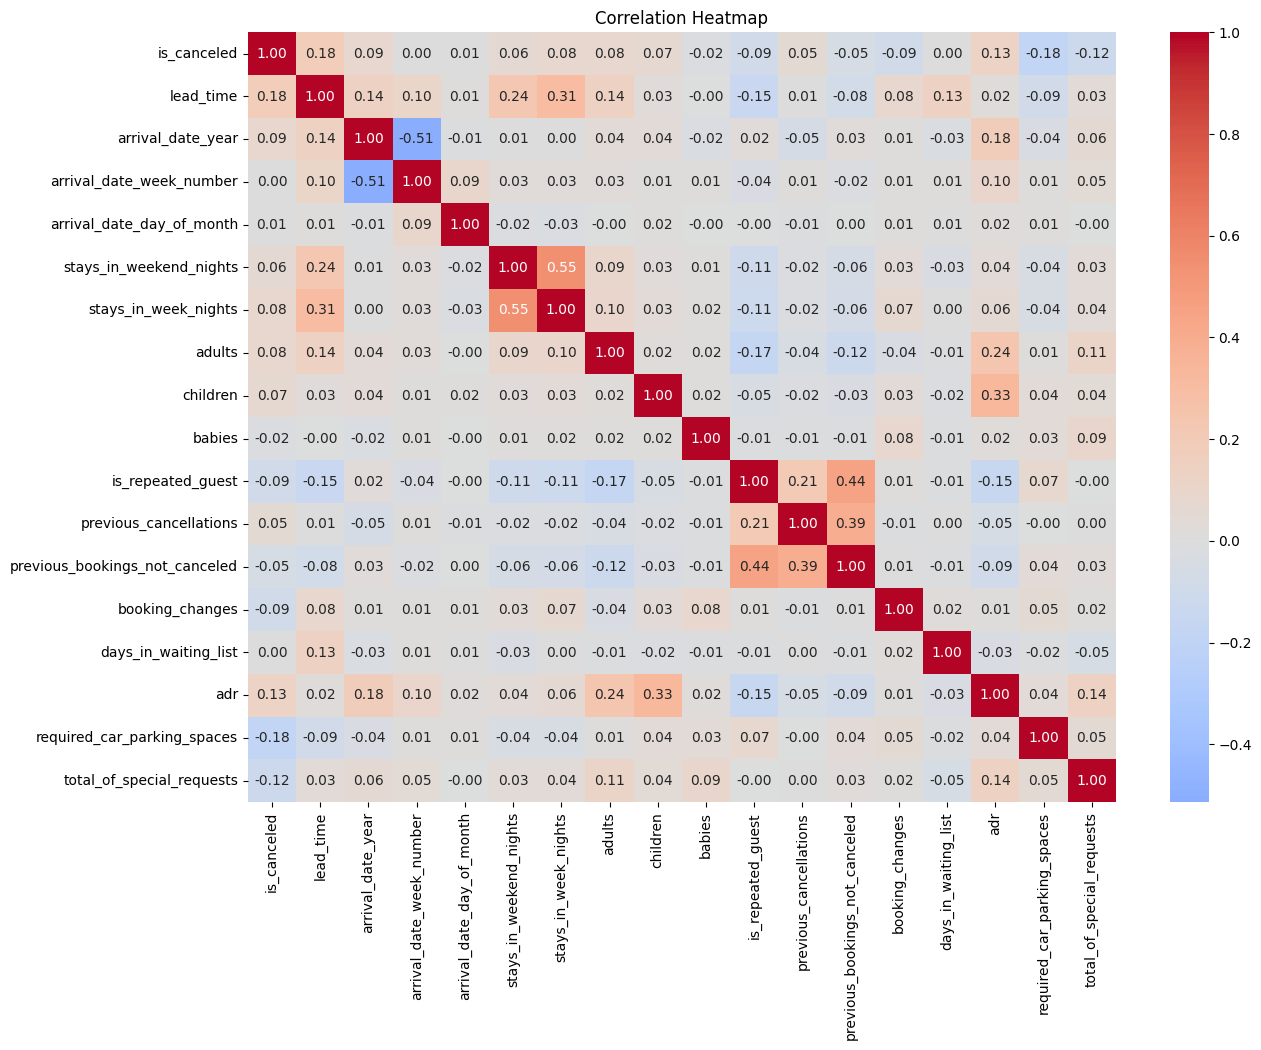

In [33]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.show()

In [34]:
corr['is_canceled'].sort_values(ascending=False)

is_canceled                       1.000000
lead_time                         0.184527
adr                               0.127221
arrival_date_year                 0.088029
stays_in_week_nights              0.084172
adults                            0.080272
children                          0.067180
stays_in_weekend_nights           0.061016
previous_cancellations            0.051500
arrival_date_day_of_month         0.005440
days_in_waiting_list              0.004710
arrival_date_week_number          0.001682
babies                           -0.020628
previous_bookings_not_canceled   -0.052171
is_repeated_guest                -0.088741
booking_changes                  -0.093223
total_of_special_requests        -0.120800
required_car_parking_spaces      -0.184459
Name: is_canceled, dtype: float64

In [35]:
bins = [0, 30, 90, 180, 365, float('inf')]
labels = ['0-30', '31-90', '91-180', '181-365', '365+']

df['lead_time_group'] = pd.cut(
    df['lead_time'],
    bins=bins,
    labels=labels
)

lead_time_cancellation = (
    df.groupby('lead_time_group', observed=True)['is_canceled']
    .mean() * 100
)

lead_time_cancellation

lead_time_group
0-30       18.624882
31-90      32.042254
91-180     35.008780
181-365    39.689064
365+       40.780142
Name: is_canceled, dtype: float64

In [36]:
pd.crosstab(
    df['lead_time_group'],
    df['hotel'],
    values=df['is_canceled'],
    aggfunc='mean'
) * 100

hotel,City Hotel,Resort Hotel
lead_time_group,,
0-30,21.446955,14.194649
31-90,33.155186,29.812269
91-180,36.716857,32.048590
181-365,44.497445,34.385569
365+,51.200000,20.105820


In [37]:
pd.crosstab(
    df['lead_time_group'],
    df['hotel']
)

hotel,City Hotel,Resort Hotel
lead_time_group,,
0-30,17485,11138
31-90,15156,7564
91-180,11556,6668
181-365,5870,5322
365+,375,189


In [38]:
bins = [0, 50, 100, 150, 200, 300, float('inf')]
labels = ['0-50', '51-100', '101-150', '151-200', '201-300', '300+']

df['adr_group'] = pd.cut(
    df['adr'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

adr_cancellation = (
    df.groupby('adr_group', observed=True)['is_canceled']
    .mean() * 100
)

adr_cancellation

adr_group
0-50       14.987639
51-100     24.476678
101-150    31.892602
151-200    33.968437
201-300    37.850572
300+       32.950192
Name: is_canceled, dtype: float64

In [39]:
pd.crosstab(
    df['adr_group'],
    df['is_canceled']
)

is_canceled,0,1
adr_group,,
0-50,8253,1455
51-100,27023,8758
101-150,18137,8493
151-200,6862,3530
201-300,2770,1687
300+,175,86


In [40]:
pd.crosstab(
    df['adr_group'],
    df['hotel'],
    values=df['is_canceled'],
    aggfunc='mean'
) * 100

hotel,City Hotel,Resort Hotel
adr_group,,
0-50,14.161657,15.138229
51-100,26.575079,20.765957
101-150,33.246703,27.084757
151-200,34.660926,32.810491
201-300,35.942392,38.916084
300+,30.232558,33.486239


In [41]:
pd.crosstab(
    df['adr_group'],
    df['hotel']
)

hotel,City Hotel,Resort Hotel
adr_group,,
0-50,1497,8211
51-100,22856,12925
101-150,20778,5852
151-200,6503,3889
201-300,1597,2860
300+,43,218


In [42]:
market_cancellation = (
    df.groupby('market_segment')['is_canceled']
    .mean()
    .sort_values(ascending=False) * 100
)

market_cancellation

C:\Users\Rawan\AppData\Local\Temp\ipykernel_21264\1886406751.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('market_segment')['is_canceled']


market_segment
Undefined        100.000000
Online TA         35.384944
Groups            27.067669
Aviation          19.911504
Offline TA/TO     14.846626
Direct            14.745331
Complementary     12.283237
Corporate         12.119048
Name: is_canceled, dtype: float64

In [43]:
pd.crosstab(
    df['market_segment'],
    df['is_canceled']
)

is_canceled,0,1
market_segment,,
Aviation,181,45
Complementary,607,85
Corporate,3691,509
Direct,10043,1737
Groups,3589,1332
Offline TA/TO,11798,2057
Online TA,33311,18242
Undefined,0,2


In [44]:
deposit_cancellation = (
    df.groupby('deposit_type')['is_canceled']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

deposit_cancellation

C:\Users\Rawan\AppData\Local\Temp\ipykernel_21264\2757945946.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('deposit_type')['is_canceled']


deposit_type
Non Refund    94.701349
No Deposit    26.718089
Refundable    24.299065
Name: is_canceled, dtype: float64

In [45]:
pd.crosstab(
    df['deposit_type'],
    df['is_canceled']
)

is_canceled,0,1
deposit_type,,
No Deposit,63084,23000
Non Refund,55,983
Refundable,81,26


In [46]:
customer_cancellation = (
    df.groupby('customer_type')['is_canceled']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

customer_cancellation

C:\Users\Rawan\AppData\Local\Temp\ipykernel_21264\1416627739.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('customer_type')['is_canceled']


customer_type
Transient          30.142495
Contract           16.331738
Transient-Party    15.251048
Group               9.796673
Name: is_canceled, dtype: float64

In [47]:
pd.crosstab(
    df['customer_type'],
    df['is_canceled']
)

is_canceled,0,1
customer_type,,
Contract,2623,512
Group,488,53
Transient,50201,21661
Transient-Party,9908,1783


In [48]:
special_requests_cancellation = (
    df.groupby('total_of_special_requests')['is_canceled']
    .mean()
    .mul(100)
)

special_requests_cancellation

total_of_special_requests
0    33.253403
1    22.435809
2    21.322594
3    17.113224
4    10.625000
5     5.555556
Name: is_canceled, dtype: float64

In [49]:
pd.crosstab(
    df['total_of_special_requests'],
    df['is_canceled']
)

is_canceled,0,1
total_of_special_requests,,
0,29227,14561
1,22475,6501
2,9280,2515
3,1918,396
4,286,34
5,34,2


In [71]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'],
    categories=month_order,
    ordered=True
)

In [72]:
monthly_bookings = (
    df['arrival_date_month']
    .value_counts()
    .sort_index()
)

monthly_bookings

arrival_date_month
January       4685
February      6083
March         7488
April         7900
May           8344
June          7756
July         10043
August       11242
September     6682
October       6921
November      4973
December      5112
Name: count, dtype: int64

In [74]:
monthly_cancellation = (
    df.groupby('arrival_date_month', observed=True)['is_canceled']
    .mean()
    .mul(100)
)

monthly_cancellation

arrival_date_month
January      22.134472
February     23.212231
March        24.425748
April        30.455696
May          29.266539
June         30.337803
July         31.823160
August       32.218466
September    24.558515
October      23.724895
November     21.154233
December     26.936620
Name: is_canceled, dtype: float64

 City Hotel bookings had a higher cancellation rate (30.1%) than Resort Hotel bookings (23.5%) in the analyzed dataset.

Cancellation rates generally increased as lead time increased, particularly for City Hotel bookings. For Resort Hotel bookings, the same upward pattern was observed through the 181–365 day range, while the 365+ group contained relatively few bookings and showed a different pattern.


Cancellation rates generally increased as ADR increased, reaching their highest observed level in the 201–300 ADR range. The 300+ group showed lower cancellation rates, but it contained substantially fewer bookings, so this decrease should be interpreted cautiously

Online TA bookings had the highest cancellation rate among the major market segments, at 35.38%, followed by Groups at 27.07%. The Undefined category showed a 100% cancellation rate, but it contained only two bookings, so it was not considered representative.

Bookings with a Non Refund deposit type had a substantially higher cancellation rate (94.70%) compared with No Deposit (26.72%) and Refundable (24.30%) bookings.


Transient customers had the highest cancellation rate at 30.14%, while Group customers had the lowest at 9.80%. Contract and Transient-Party customers had cancellation rates of 16.33% and 15.25%, respectively.

Cancellation rates decreased as the number of special requests increased, from 33.25% for bookings with no special requests to 10.63% for bookings with four special requests. The five-request group had only 36 bookings, so its 5.56% cancellation rate should be interpreted cautiously.

## Visualization

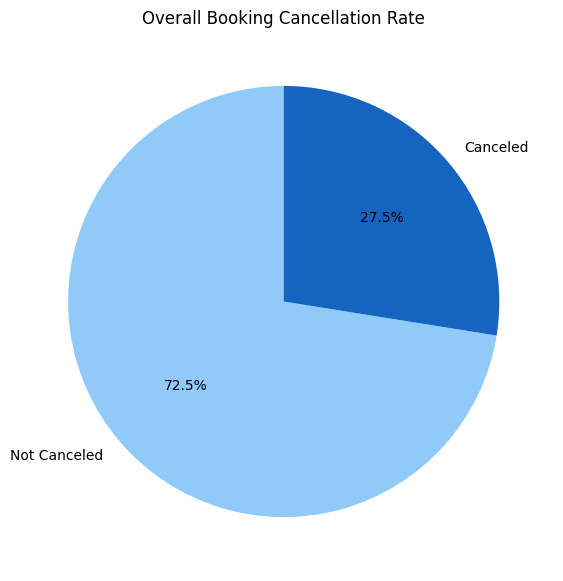

In [61]:
import matplotlib.pyplot as plt

cancellation_counts = df['is_canceled'].value_counts()

labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(7, 7))

plt.pie(
    cancellation_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#90CAF9', '#1565C0']
)

plt.title('Overall Booking Cancellation Rate')

plt.show()

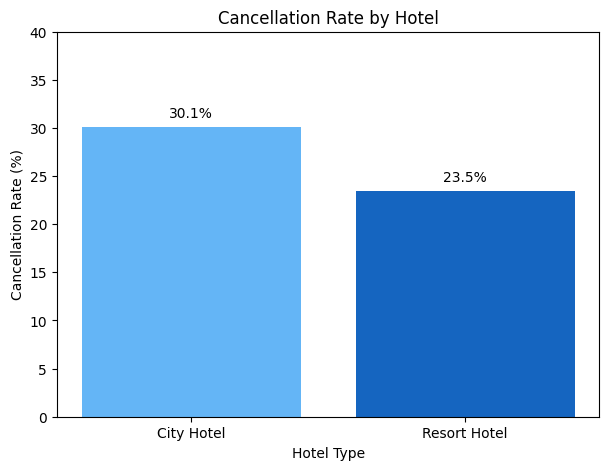

In [54]:
 

plt.figure(figsize=(7, 5))

bars = plt.bar(
    hotel_cancellation.index,
    hotel_cancellation.values,
    color=['#64B5F6', '#1565C0']
)

plt.title('Cancellation Rate by Hotel')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 40)

for bar, value in zip(bars, hotel_cancellation.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f'{value:.1f}%',
        ha='center'
    )

plt.show()

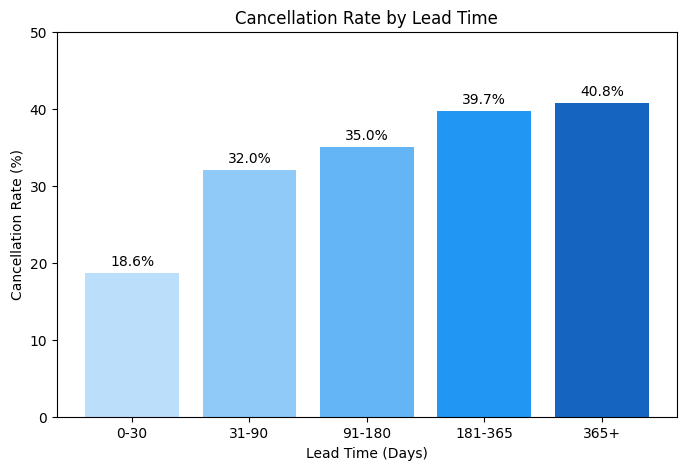

In [56]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    lead_time_cancellation.index.astype(str),
    lead_time_cancellation.values,
    color=[
        '#BBDEFB',
        '#90CAF9',
        '#64B5F6',
        '#2196F3',
        '#1565C0'
    ]
)

plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 50)

for bar, value in zip(bars, lead_time_cancellation.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f'{value:.1f}%',
        ha='center'
    )

plt.show()

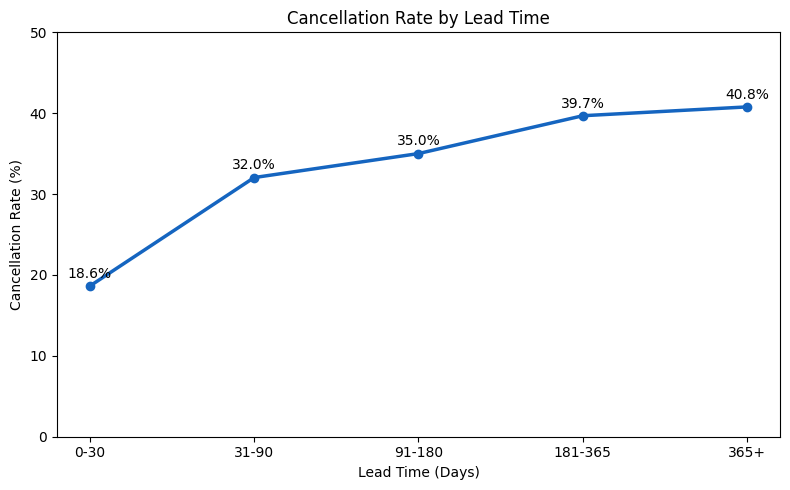

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    lead_time_cancellation.index.astype(str),
    lead_time_cancellation.values,
    marker='o',
    linewidth=2.5,
    color='#1565C0'
)

plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 50)

for x, y in zip(
    lead_time_cancellation.index.astype(str),
    lead_time_cancellation.values
):
    plt.text(
        x,
        y + 1,
        f'{y:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

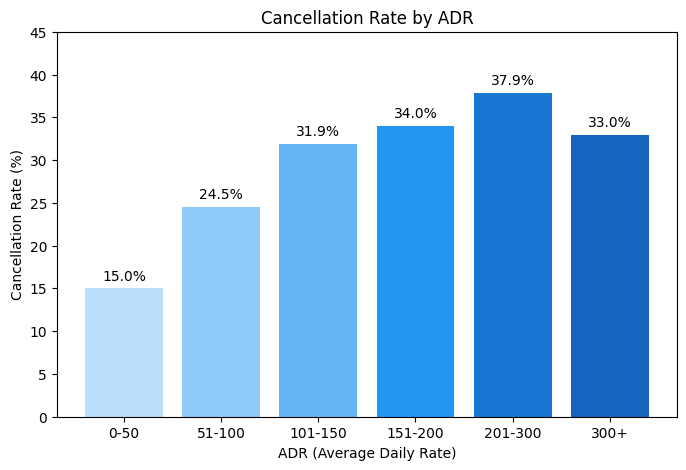

In [57]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    adr_cancellation.index.astype(str),
    adr_cancellation.values,
    color=[
        '#BBDEFB',
        '#90CAF9',
        '#64B5F6',
        '#2196F3',
        '#1976D2',
        '#1565C0'
    ]
)

plt.title('Cancellation Rate by ADR')
plt.xlabel('ADR (Average Daily Rate)')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 45)

for bar, value in zip(bars, adr_cancellation.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f'{value:.1f}%',
        ha='center'
    )

plt.show()

C:\Users\Rawan\AppData\Local\Temp\ipykernel_21264\2352117485.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('market_segment')['is_canceled']


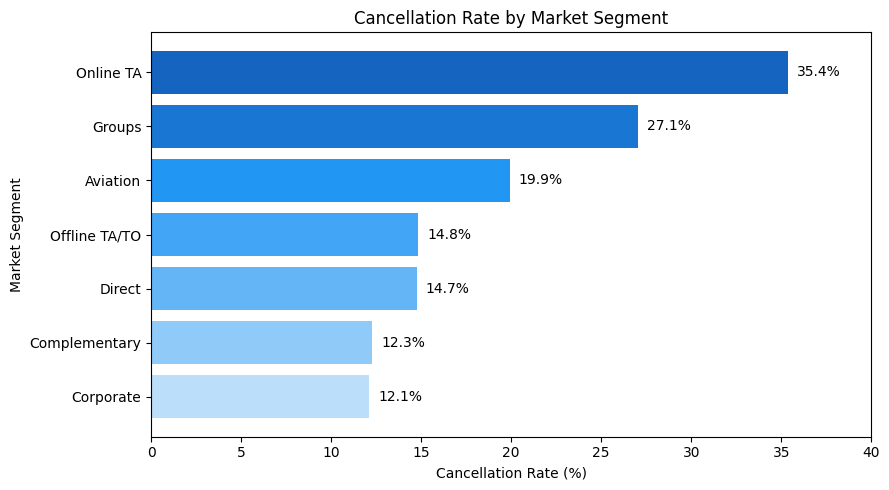

In [64]:
market_cancellation = (
    df.groupby('market_segment')['is_canceled']
    .mean()
    .mul(100)
    .sort_values()
)

market_cancellation = market_cancellation.drop('Undefined')

plt.figure(figsize=(9, 5))

bars = plt.barh(
    market_cancellation.index,
    market_cancellation.values,
    color=[
        '#BBDEFB',
        '#90CAF9',
        '#64B5F6',
        '#42A5F5',
        '#2196F3',
        '#1976D2',
        '#1565C0'
    ]
)

plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Market Segment')
plt.xlim(0, 40)

for bar, value in zip(bars, market_cancellation.values):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{value:.1f}%',
        va='center'
    )

plt.tight_layout()
plt.show()

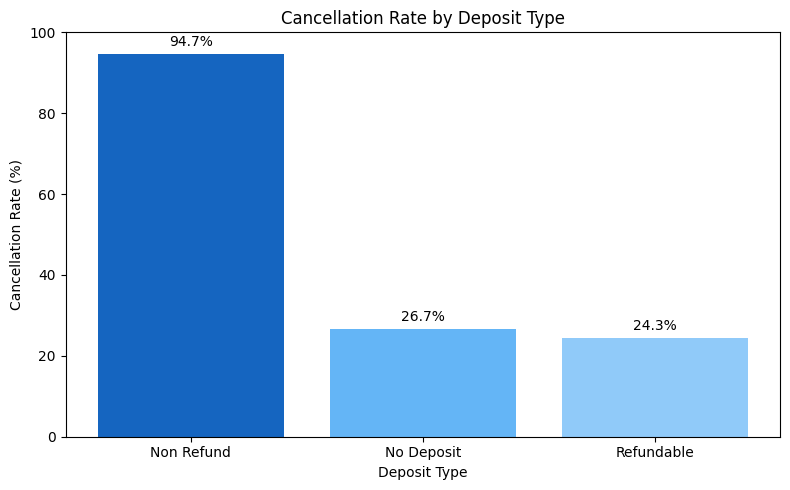

In [66]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    deposit_cancellation.index,
    deposit_cancellation.values,
    color=['#1565C0', '#64B5F6', '#90CAF9']
)

plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 100)

for bar, value in zip(bars, deposit_cancellation.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 2,
        f'{value:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

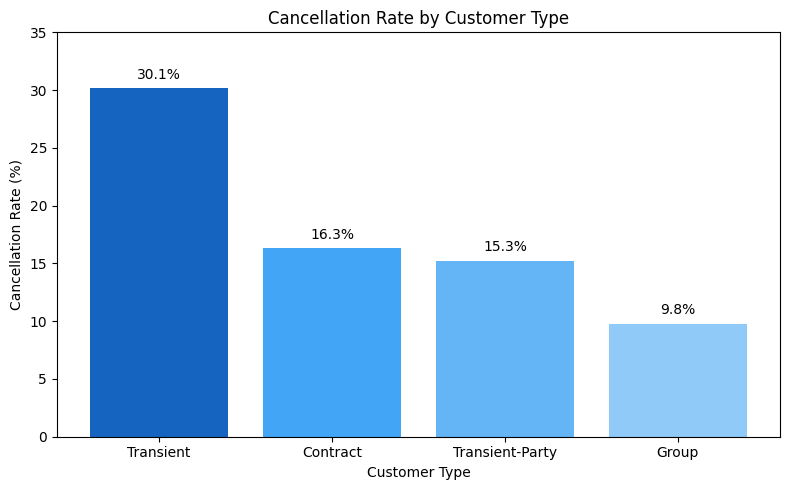

In [68]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    customer_cancellation.index,
    customer_cancellation.values,
    color=['#1565C0', '#42A5F5', '#64B5F6', '#90CAF9']
)

plt.title('Cancellation Rate by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 35)

for bar, value in zip(bars, customer_cancellation.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.8,
        f'{value:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

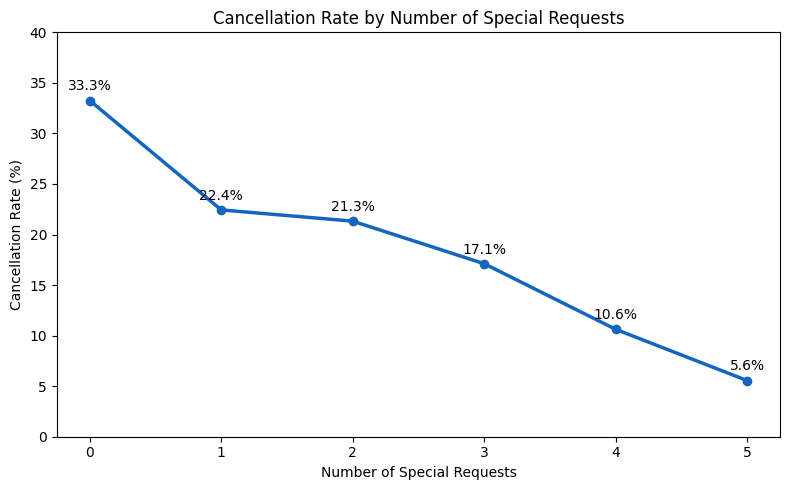

In [70]:
plt.figure(figsize=(8, 5))

plt.plot(
    special_requests_cancellation.index,
    special_requests_cancellation.values,
    marker='o',
    linewidth=2.5,
    color='#1565C0'
)

plt.title('Cancellation Rate by Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(special_requests_cancellation.index)
plt.ylim(0, 40)

for x, y in zip(
    special_requests_cancellation.index,
    special_requests_cancellation.values
):
    plt.text(
        x,
        y + 1,
        f'{y:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

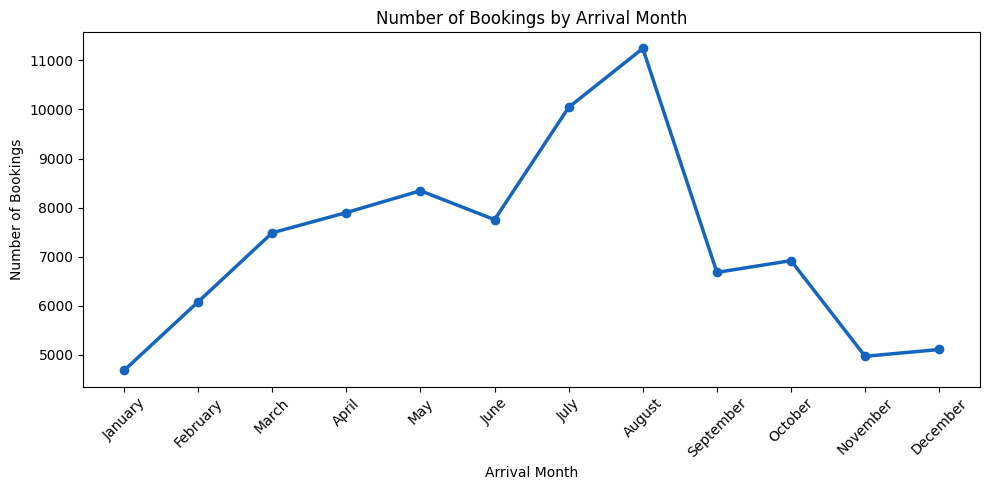

In [73]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_bookings.index,
    monthly_bookings.values,
    marker='o',
    linewidth=2.5,
    color='#1565C0'
)

plt.title('Number of Bookings by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

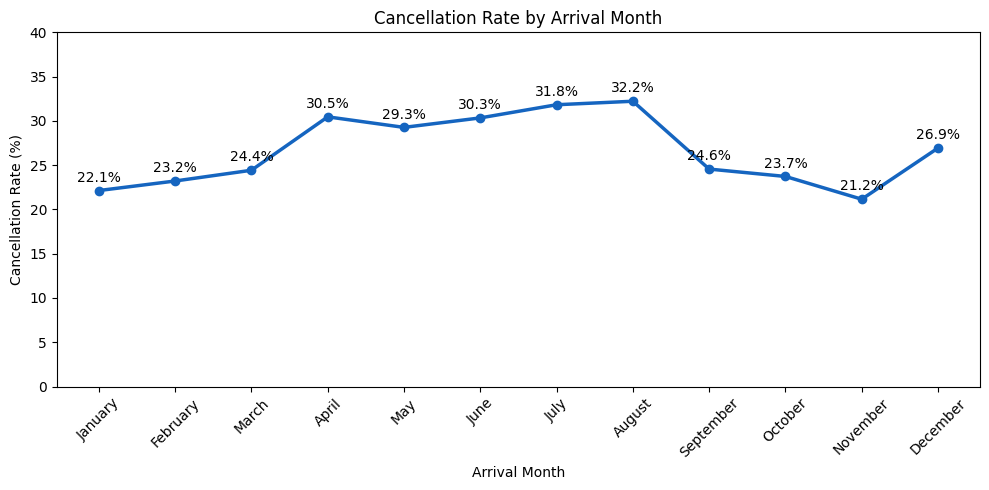

In [75]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_cancellation.index,
    monthly_cancellation.values,
    marker='o',
    linewidth=2.5,
    color='#1565C0'
)

plt.title('Cancellation Rate by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 40)

for x, y in zip(
    monthly_cancellation.index,
    monthly_cancellation.values
):
    plt.text(
        x,
        y + 1,
        f'{y:.1f}%',
        ha='center'
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()